# BÀI THỰC HÀNH 02. CÁC PHÉP TOÁN SỐ HỌC & LOGIC - TÍCH CHẬP 2D

## 0. Cài đặt Môi trường & Các hàm Tiện ích

Chạy ô mã bên dưới để tải các thư viện cần thiết và khai báo các hàm hỗ trợ chung.


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def read_gray_cv2(path: str) -> np.ndarray:
    """Đọc ảnh xám -> mảng uint8 [H,W] trong khoảng giá trị [0..255]."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Không thể đọc được ảnh: {path}")
    return img

def to_float01(img_u8: np.ndarray) -> np.ndarray:
    """Chuyển đổi kiểu uint8 [0..255] thành kiểu float32 [0..1]."""
    return img_u8.astype(np.float32) / 255.0

def to_uint8(img_float01: np.ndarray) -> np.ndarray:
    """Chuyển đổi kiểu float [0..1] thành kiểu uint8 [0..255] (có giới hạn biên - clip)."""
    x = np.clip(img_float01, 0.0, 1.0)
    return (x * 255.0 + 0.5).astype(np.uint8)

def show_gray(img_u8: np.ndarray, title: str = "") -> None:
    """Hiển thị ảnh xám bằng thư viện matplotlib."""
    plt.figure()
    plt.imshow(img_u8, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
    plt.show()

def save_gray(path: str, img_u8: np.ndarray) -> None:
    """Lưu ảnh xám ra file."""
    cv2.imwrite(path, img_u8)

def show_multiple_gray(images, titles, columns=4, figsize=(16, 4)):
    """Hàm tiện ích để hiển thị nhiều ảnh cạnh nhau trên cùng một dòng."""
    n = len(images)
    rows = (n + columns - 1) // columns
    plt.figure(figsize=(figsize[0], figsize[1] * rows))
    for i in range(n):
        plt.subplot(rows, columns, i + 1)
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


## 1.1 Hiệu chỉnh Gamma (Power-law Transform)

Cài đặt phương pháp Hiệu chỉnh Gamma bằng NumPy và OpenCV.
Chạy bài tập nhỏ (Mini-Task) áp dụng phương pháp này với ảnh mẫu `gamma_example.png` để phân tích kết quả.


--- Bài tập nhỏ: Hiệu chỉnh Gamma ---


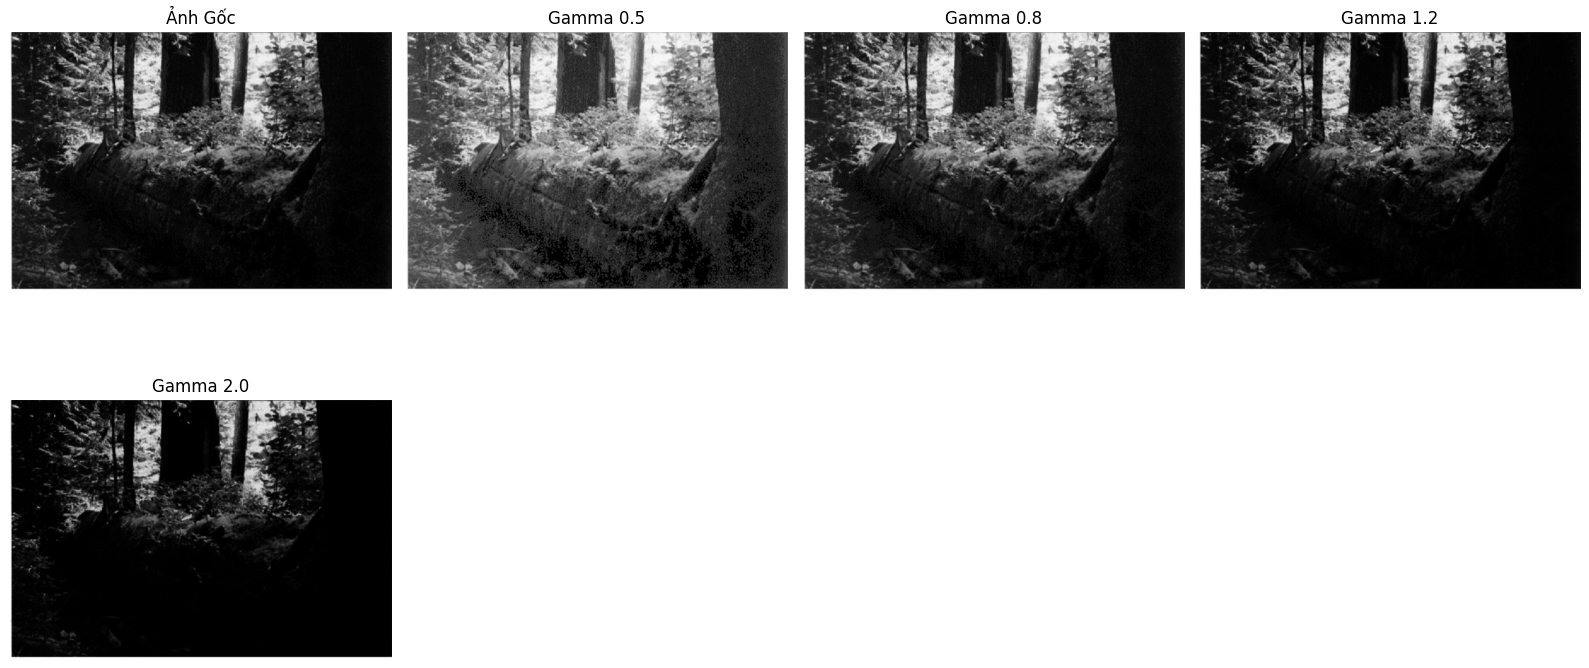

Thảo luận kết quả:
- Khi gamma < 1 (ví dụ 0.5, 0.8), vùng tối của ảnh được làm sáng lên (mở rộng bóng tối, tăng chi tiết chìm).
- Khi gamma > 1 (ví dụ 1.2, 2.0), vùng sáng của ảnh bị làm tối đi (mở rộng vùng sáng, nén bóng tối).
- Quan sát thấy nền xám phía sau ảnh gamma_example thay đổi rõ rệt nhất khi ta dùng gamma < 1 nhằm bóc tách các mảng tối.


In [3]:
def gamma_correction_np(img_u8: np.ndarray, gamma: float) -> np.ndarray:
    """ Công thức hiệu chỉnh: s = r^gamma (với r trong khoảng [0,1]) """
    if gamma <= 0:
        raise ValueError("Yêu cầu giá trị gamma > 0")
    r = to_float01(img_u8)
    s = np.power(r, gamma)
    return to_uint8(s)

def gamma_correction_cv2(img_u8: np.ndarray, gamma: float) -> np.ndarray:
    if gamma <= 0:
        raise ValueError("Yêu cầu giá trị gamma > 0")
    # Sử dụng Bảng tra cứu (Look-up Table - LUT) để các tính toán nhanh hơn
    table = np.array([((i / 255.0) ** gamma) * 255.0 for i in range(256)], dtype=np.uint8)
    return cv2.LUT(img_u8, table)

# Bài tập nhỏ: Hiệu chỉnh Gamma
print("--- Bài tập nhỏ: Hiệu chỉnh Gamma ---")
img_gamma = read_gray_cv2('../Resources/gamma_example.png')
gammas = [0.5, 0.8, 1.2, 2.0]
results = [img_gamma]
titles = ["Ảnh Gốc"]
for g in gammas:
    results.append(gamma_correction_np(img_gamma, g))
    titles.append(f"Gamma {g}")
show_multiple_gray(results, titles)

print("""Thảo luận kết quả:
- Khi gamma < 1 (ví dụ 0.5, 0.8), vùng tối của ảnh được làm sáng lên (mở rộng bóng tối, tăng chi tiết chìm).
- Khi gamma > 1 (ví dụ 1.2, 2.0), vùng sáng của ảnh bị làm tối đi (mở rộng vùng sáng, nén bóng tối).
- Quan sát thấy nền xám phía sau ảnh gamma_example thay đổi rõ rệt nhất khi ta dùng gamma < 1 nhằm bóc tách các mảng tối.""")


## 1.2 Các Phép toán Số học

Thực hiện các phép Cộng, Trừ, Nhân, Chia trên ảnh bằng code tự lập trình với NumPy, và so sánh với thao tác của OpenCV.


--- Bài tập nhỏ: Các Phép toán Số học ---
Kết quả NumPy (Quy chuẩn về Float và có giới hạn dải số):


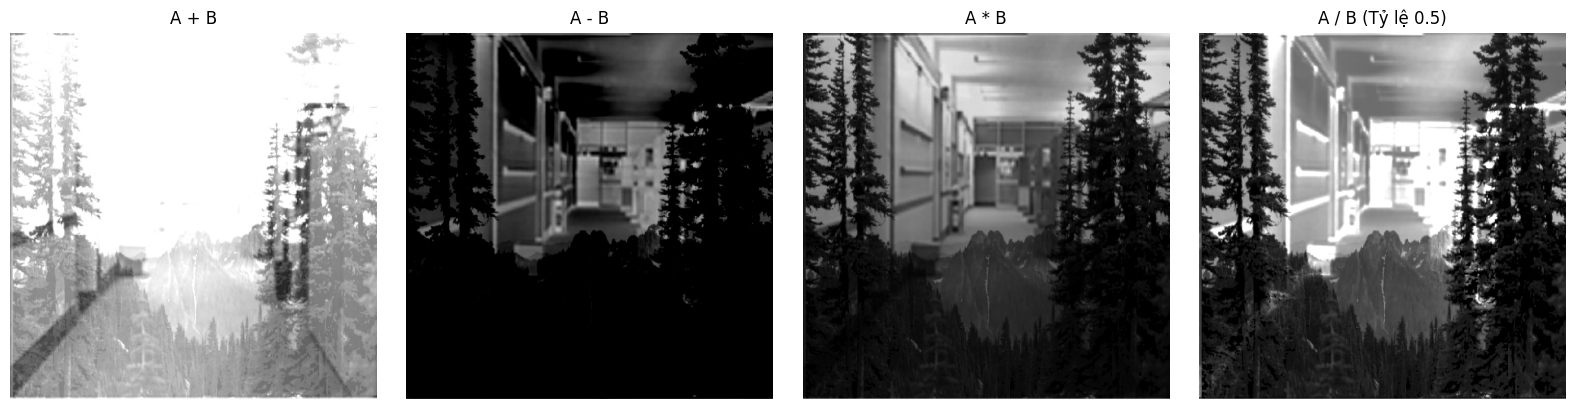

Kết quả OpenCV (Thao tác số nguyên và giới hạn tràn số <= 255):


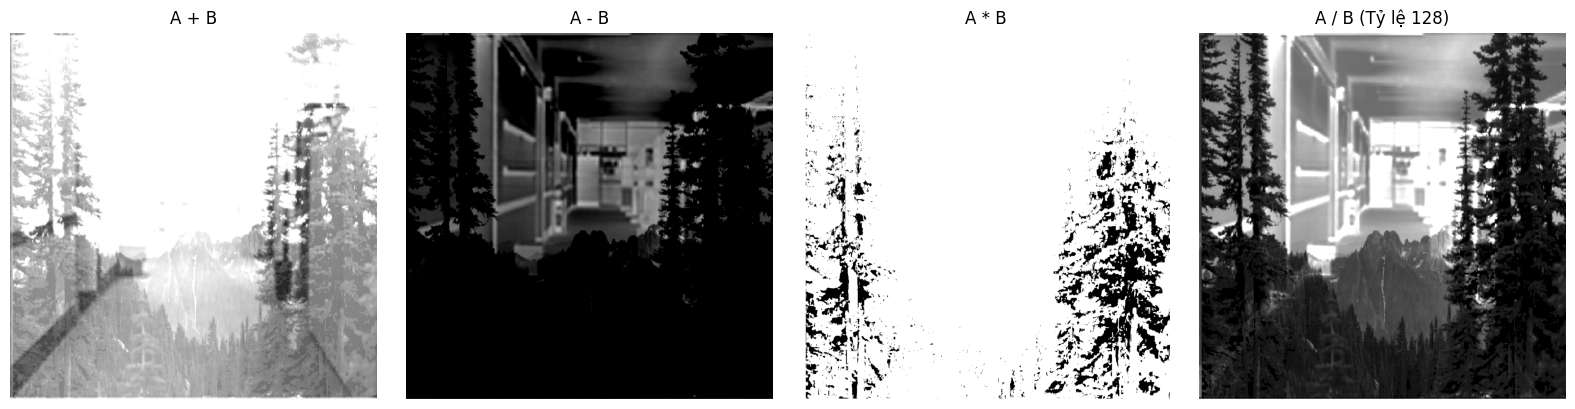

Thảo luận:
- NumPy (Kiểu float + cắt cụt giá trị): Chuẩn hóa cường độ ánh sáng về dải [0, 1], tính toán và cắt các kết quả lớn hơn 1 thành 255. Điểm chú ý là phép chia tác động quá mức lên các vùng có độ nhạy sáng.
- OpenCV (Có bão hòa): Dùng toàn bộ số nguyên int giới hạn tự động cao nhất tại 255 (tránh việc tràn bộ đệm).
- Phép Trừ rất hữu dụng để phát hiện những sự thay đổi (Change detection) vì tính chất giúp triệt tiêu hoàn toàn những phần tĩnh (nền giống nhau) của 2 hình.
- Phép Chia cực kì dễ tạo ra những kết quả cực lớn. Chia một số nhỏ sẽ cho kết quả phình to gấp bội.
- Việc cắt bằng hàm np.clip làm ẩn chi tiết, ví dụ ngưỡng đã vượt qua 1.0 (255) bị trắng xóa và làm mật độ tương phản ở những vùng siêu sáng biến mất.


In [4]:
def add_images_np(a: np.ndarray, b: np.ndarray, alpha=1.0, beta=1.0) -> np.ndarray:
    """Phép cộng: S = alpha*a + beta*b"""
    S = alpha * to_float01(a) + beta * to_float01(b)
    return to_uint8(S)

def sub_images_np(a: np.ndarray, b: np.ndarray, alpha=1.0, beta=1.0) -> np.ndarray:
    """Phép trừ: S = alpha*a - beta*b"""
    S = alpha * to_float01(a) - beta * to_float01(b)
    return to_uint8(S)

def mul_images_np(a: np.ndarray, b: np.ndarray, scale=1.0) -> np.ndarray:
    """Phép nhân: S = scale*(a * b)"""
    S = scale * (to_float01(a) * to_float01(b))
    return to_uint8(S)

def div_images_np(a: np.ndarray, b: np.ndarray, eps=1e-6, scale=1.0) -> np.ndarray:
    """Phép chia: S = scale*(a / b)"""
    S = scale * (to_float01(a) / (to_float01(b) + eps))
    return to_uint8(S)

def add_images_cv2(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    return cv2.add(a, b)

def sub_images_cv2(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    return cv2.subtract(a, b)

def mul_images_cv2(a: np.ndarray, b: np.ndarray, scale=1.0) -> np.ndarray:
    return cv2.multiply(a, b, scale=scale)

def div_images_cv2(a: np.ndarray, b: np.ndarray, scale=1.0) -> np.ndarray:
    return cv2.divide(a, np.maximum(b, 1).astype(np.uint8), scale=scale)

# Bài tập nhỏ: Thao tác Số học
print("--- Bài tập nhỏ: Các Phép toán Số học ---")
A = read_gray_cv2('../Resources/1.png')
B = read_gray_cv2('../Resources/1_background.png')

# Thay đổi kích thước ảnh B (nhỏ) cho khớp với ảnh A để có thể tính toán chung
B = cv2.resize(B, (A.shape[1], A.shape[0]))

print("Kết quả NumPy (Quy chuẩn về Float và có giới hạn dải số):")
show_multiple_gray([add_images_np(A, B), sub_images_np(A, B), mul_images_np(A, B), div_images_np(A, B, scale=0.5)], ["A + B", "A - B", "A * B", "A / B (Tỷ lệ 0.5)"])

print("Kết quả OpenCV (Thao tác số nguyên và giới hạn tràn số <= 255):")
show_multiple_gray([add_images_cv2(A, B), sub_images_cv2(A, B), mul_images_cv2(A, B), div_images_cv2(A, B, scale=128.0)], ["A + B", "A - B", "A * B", "A / B (Tỷ lệ 128)"])

print("""Thảo luận:
- NumPy (Kiểu float + cắt cụt giá trị): Chuẩn hóa cường độ ánh sáng về dải [0, 1], tính toán và cắt các kết quả lớn hơn 1 thành 255. Điểm chú ý là phép chia tác động quá mức lên các vùng có độ nhạy sáng.
- OpenCV (Có bão hòa): Dùng toàn bộ số nguyên int giới hạn tự động cao nhất tại 255 (tránh việc tràn bộ đệm).
- Phép Trừ rất hữu dụng để phát hiện những sự thay đổi (Change detection) vì tính chất giúp triệt tiêu hoàn toàn những phần tĩnh (nền giống nhau) của 2 hình.
- Phép Chia cực kì dễ tạo ra những kết quả cực lớn. Chia một số nhỏ sẽ cho kết quả phình to gấp bội.
- Việc cắt bằng hàm np.clip làm ẩn chi tiết, ví dụ ngưỡng đã vượt qua 1.0 (255) bị trắng xóa và làm mật độ tương phản ở những vùng siêu sáng biến mất.""")


## 1.3 Các Phép toán Logic (AND / OR / XOR)

Áp dụng bộ phép tính hình học đại số Boolean trực tiếp lên các điểm ảnh của mặt nạ nhị phân.


--- Bài tập nhỏ: Các Phép toán Logic ---


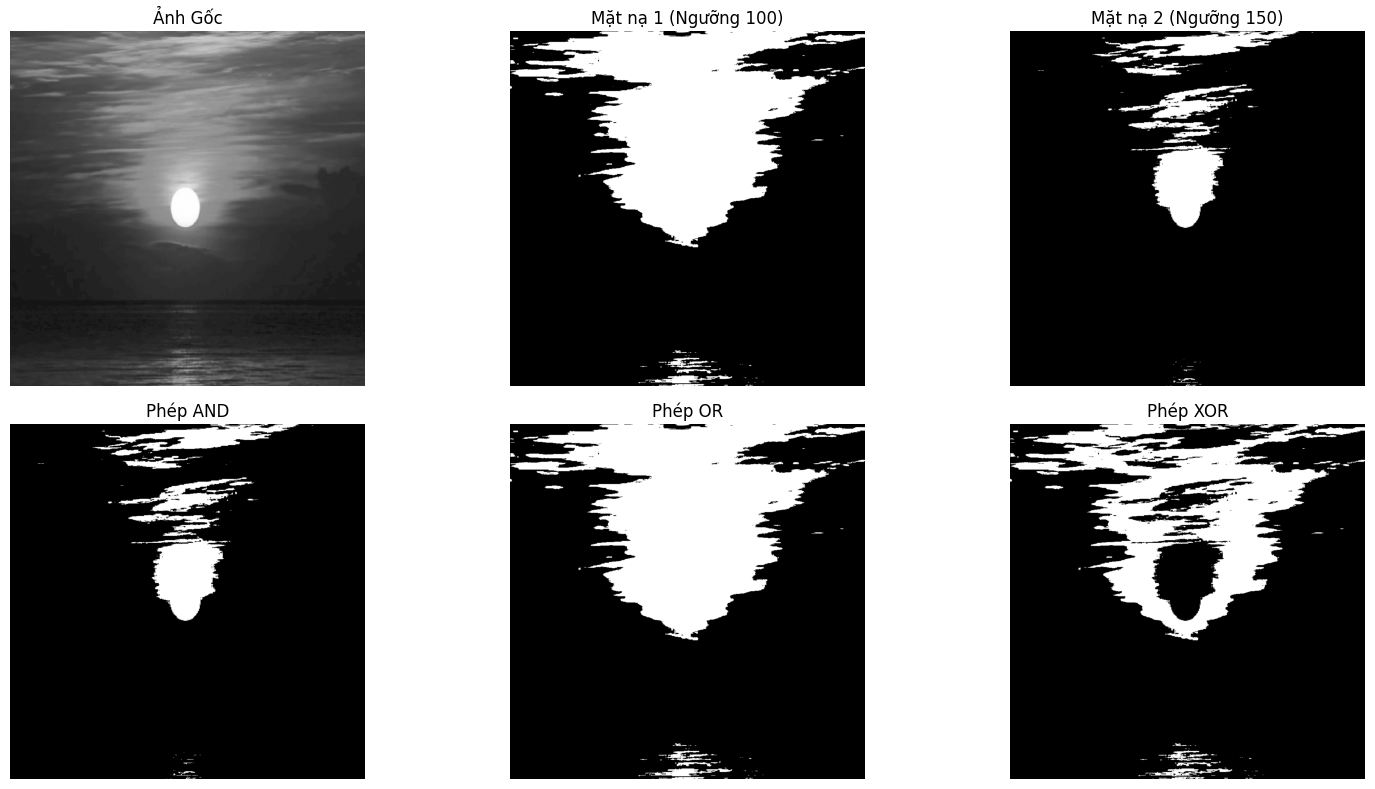

Thảo luận:
- Phép 'AND' (VÀ) giúp thu hẹp lại, chỉ giữ các vùng chắc chắn đúng do chúng xuất hiện chung ở cả hai mặt nạ.
- Phép 'OR' (HOẶC) mang tính chất hợp nhất, bao trùm tổng thể tất cả các lựa chọn khả dĩ từ cả hai mặt nạ.


In [5]:
def threshold_binary_np(img_u8: np.ndarray, t: int) -> np.ndarray:
    """Phân ngưỡng: Nếu giá trị >= t trả về 255 (trắng), ngược lại là 0 (đen)."""
    return np.where(img_u8 >= t, 255, 0).astype(np.uint8)

def and_images_np(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    return np.where((a == 255) & (b == 255), 255, 0).astype(np.uint8)

def or_images_np(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    return np.where((a == 255) | (b == 255), 255, 0).astype(np.uint8)

def xor_images_np(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    return np.where((a == 255) ^ (b == 255), 255, 0).astype(np.uint8)

# Bài tập nhỏ: Thao tác Logic
print("--- Bài tập nhỏ: Các Phép toán Logic ---")
img_logic = read_gray_cv2('../Resources/2.png')

# Tạo 2 mặt nạ bằng 2 ngưỡng phân loại khác nhau:
mask1 = threshold_binary_np(img_logic, 100)
mask2 = threshold_binary_np(img_logic, 150)

titles = ["Ảnh Gốc", "Mặt nạ 1 (Ngưỡng 100)", "Mặt nạ 2 (Ngưỡng 150)", "Phép AND", "Phép OR", "Phép XOR"]
show_multiple_gray([img_logic, mask1, mask2, and_images_np(mask1, mask2), or_images_np(mask1, mask2), xor_images_np(mask1, mask2)], titles, columns=3)

print("""Thảo luận:
- Phép 'AND' (VÀ) giúp thu hẹp lại, chỉ giữ các vùng chắc chắn đúng do chúng xuất hiện chung ở cả hai mặt nạ.
- Phép 'OR' (HOẶC) mang tính chất hợp nhất, bao trùm tổng thể tất cả các lựa chọn khả dĩ từ cả hai mặt nạ.""")


## 1.4 Phân ngưỡng Tự động Otsu

Thuật toán tự động tìm được điểm nhị phân phân tách Tối/Sáng hiệu quả nhất cho ảnh thay vì gán ngưỡng bằng tay.


--- Bài tập nhỏ: Phân ngưỡng Tự động Otsu ---


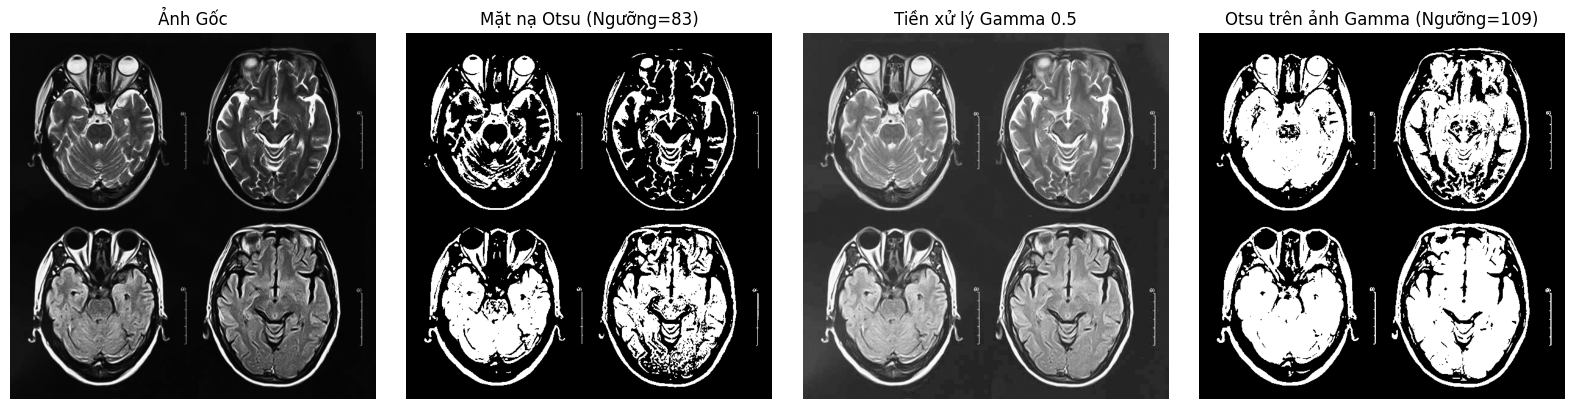

Thảo luận:
- Cơ chế của Otsu dựa trên việc xác định ranh giới tại chỗ Histogram (biểu đồ tần suất điểm ảnh) có thể chia ảnh rõ rãng làm hai nửa là Tiền cảnh và Hậu cảnh.
- Việc áp dụng gamma < 1 hỗ trợ giãn biên độ của vùng điểm ảnh ở phe bị thiếu sáng. Nhờ thế biểu đồ phân bố điểm ảnh dễ phân đôi hơn (hiệu ứng bimodal), thuận lợi cho hàm Otsu tìm điểm gãy hoàn hảo để không gom dồn vùng bị nhiễu do tối vào nền.


In [6]:
def otsu_threshold_np(img_u8: np.ndarray) -> int:
    """Giải thuật phân chia khoảng Variance lớn nhất giữa hai tập hợp (Between-class Variance)"""
    hist = np.bincount(img_u8.ravel(), minlength=256).astype(np.float64)
    N = hist.sum()
    if N == 0: return 0
    p = hist / N
    omega = np.cumsum(p)  # Xác suất tích lũy của lớp thứ nhất
    mu = np.cumsum(p * np.arange(256))
    mu_T = mu[-1]         # Cường độ ánh sáng trung bình của toàn ảnh
    
    w0, w1 = omega, 1.0 - omega
    mu0 = mu / (w0 + 1e-12)
    mu1 = (mu_T - mu) / (w1 + 1e-12)
    sigma_b2 = w0 * w1 * (mu0 - mu1)**2
    return int(np.argmax(sigma_b2))  # Tìm điểm làm cực đại phương sai

def otsu_binarize_np(img_u8: np.ndarray):
    t = otsu_threshold_np(img_u8)
    return t, threshold_binary_np(img_u8, t)

def otsu_binarize_cv2(img_u8: np.ndarray):
    t, bin_img = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return int(t), bin_img

# Bài tập nhỏ: Otsu
print("--- Bài tập nhỏ: Phân ngưỡng Tự động Otsu ---")
img_otsu = read_gray_cv2('../Resources/threshold_ostu1.jpg')
t1, mask1 = otsu_binarize_np(img_otsu)

# Thử qua bước tiền xử lý bằng Gamma trước khi đưa vào hàm Otsu
img_g = gamma_correction_np(img_otsu, 0.5)
t2, mask2 = otsu_binarize_np(img_g)

show_multiple_gray([img_otsu, mask1, img_g, mask2], ["Ảnh Gốc", f"Mặt nạ Otsu (Ngưỡng={t1})", "Tiền xử lý Gamma 0.5", f"Otsu trên ảnh Gamma (Ngưỡng={t2})"])

print("""Thảo luận:
- Cơ chế của Otsu dựa trên việc xác định ranh giới tại chỗ Histogram (biểu đồ tần suất điểm ảnh) có thể chia ảnh rõ rãng làm hai nửa là Tiền cảnh và Hậu cảnh.
- Việc áp dụng gamma < 1 hỗ trợ giãn biên độ của vùng điểm ảnh ở phe bị thiếu sáng. Nhờ thế biểu đồ phân bố điểm ảnh dễ phân đôi hơn (hiệu ứng bimodal), thuận lợi cho hàm Otsu tìm điểm gãy hoàn hảo để không gom dồn vùng bị nhiễu do tối vào nền.""")


## 1.5 Bài tập Tích hợp sau Phần 1

Nhiệm vụ: Sử dụng liên kết đường ống (Pipelines) với nhiều phương pháp phối hợp với nhau nhằm thực hiện một bài toán nhất định.


Bài tập 1: Làm sáng sau đó Áp dụng Otsu


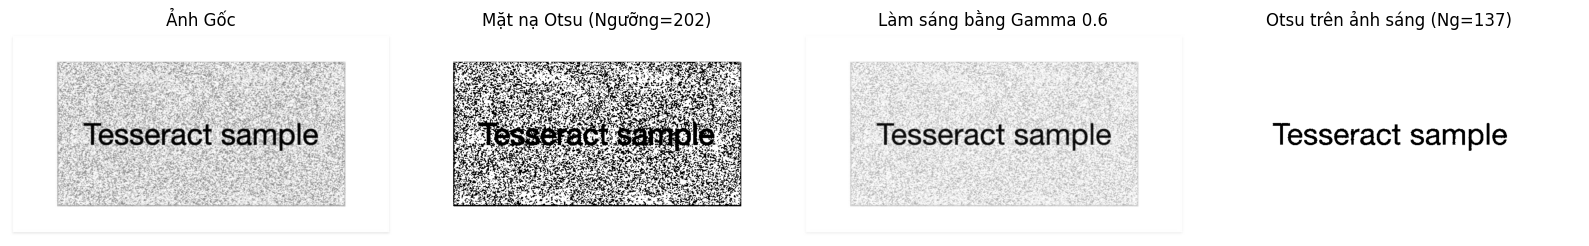


Bài tập 2: Trích xuất Cấu trúc quan tâm (ROI) bằng hàm AND


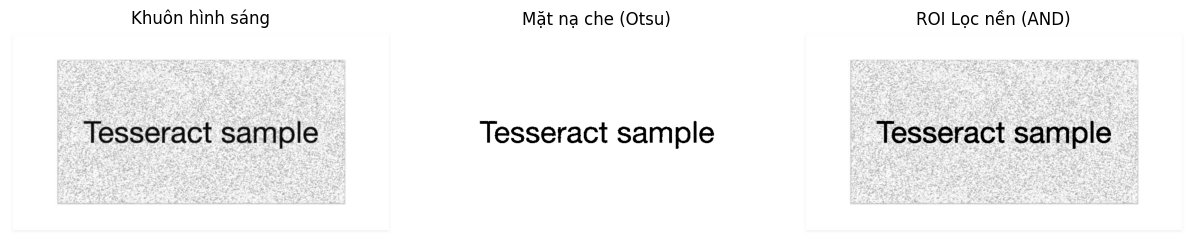


Bài tập 3: Dò tìm điểm Mới/Sự Thay đổi


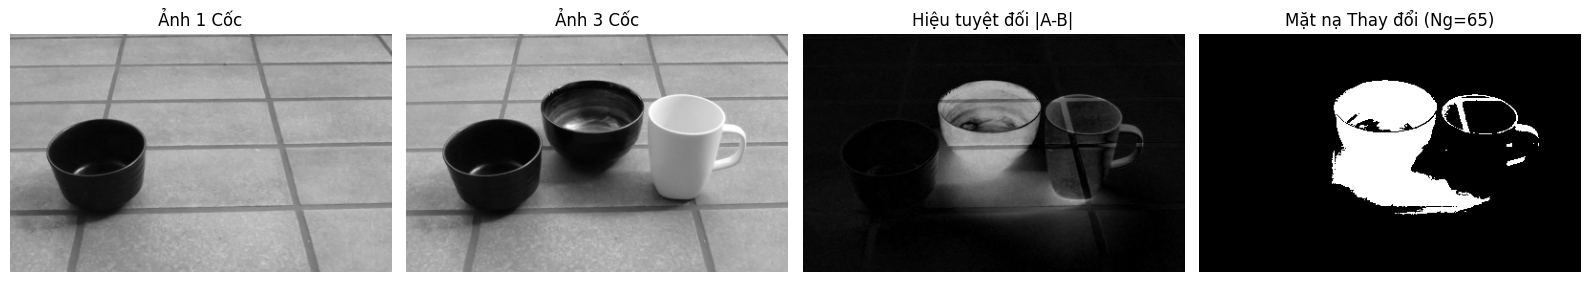


Bài tập 4: Phối hợp Mặt nạ phân tầng


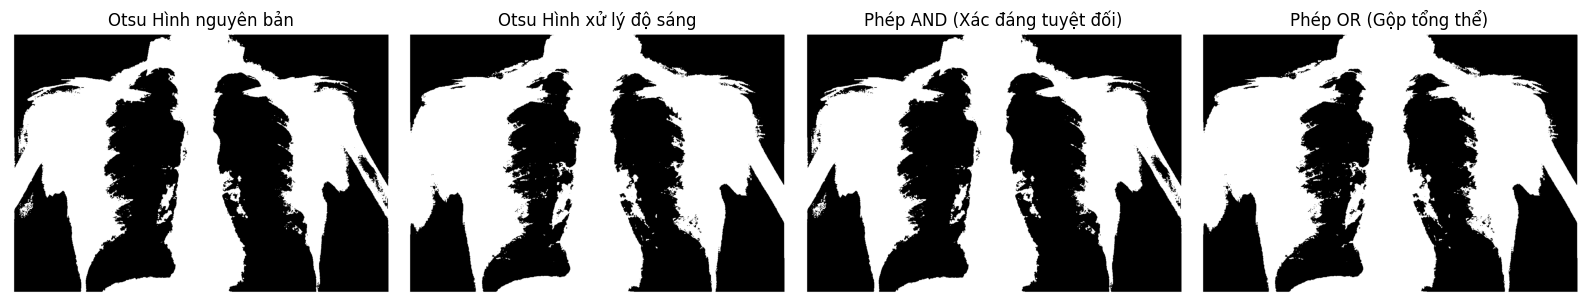

In [7]:
print("Bài tập 1: Làm sáng sau đó Áp dụng Otsu")
ex1_img = read_gray_cv2('../Resources/threshold1.jpg')
t1_orig, mask1_orig = otsu_binarize_np(ex1_img)
ex1_bright = gamma_correction_np(ex1_img, 0.6)  # Nâng cao độ sáng
t1_bright, mask1_bright = otsu_binarize_np(ex1_bright)
show_multiple_gray([ex1_img, mask1_orig, ex1_bright, mask1_bright], ["Ảnh Gốc", f"Mặt nạ Otsu (Ngưỡng={t1_orig})", "Làm sáng bằng Gamma 0.6", f"Otsu trên ảnh sáng (Ng={t1_bright})"])

print("\nBài tập 2: Trích xuất Cấu trúc quan tâm (ROI) bằng hàm AND")
# Giao thoa giữa hình thật (đã làm sáng) với mặt nạ nhị phân
roi = and_images_np(ex1_bright, mask1_bright)
# Ta cũng có thể ứng dụng hàm cv2.bitwise_and có sẵn tương đương
roi_cv2 = cv2.bitwise_and(ex1_bright, mask1_bright)
show_multiple_gray([ex1_bright, mask1_bright, roi_cv2], ["Khuôn hình sáng", "Mặt nạ che (Otsu)", "ROI Lọc nền (AND)"])

print("\nBài tập 3: Dò tìm điểm Mới/Sự Thay đổi")
A_cups = read_gray_cv2('../Resources/cups_one_bw.png')
B_cups = read_gray_cv2('../Resources/cups_three_bw.png')
# Thực hiện phép lấy mức sai lệch chuẩn dựa trên trị tuyệt đối (Absolute difference |A - B|)
diff = np.abs(to_float01(A_cups) - to_float01(B_cups))
diff_u8 = to_uint8(diff)
t_diff, mask_diff = otsu_binarize_np(diff_u8)
show_multiple_gray([A_cups, B_cups, diff_u8, mask_diff], ["Ảnh 1 Cốc", "Ảnh 3 Cốc", "Hiệu tuyệt đối |A-B|", f"Mặt nạ Thay đổi (Ng={t_diff})"])

print("\nBài tập 4: Phối hợp Mặt nạ phân tầng")
ex4_img = read_gray_cv2('../Resources/threshold_chest1.jpg')
t4_a, mask4_a = otsu_binarize_np(ex4_img)
t4_b, mask4_b = otsu_binarize_np(gamma_correction_np(ex4_img, 0.6))
fused_and = and_images_np(mask4_a, mask4_b)
fused_or = or_images_np(mask4_a, mask4_b)
show_multiple_gray([mask4_a, mask4_b, fused_and, fused_or], ["Otsu Hình nguyên bản", "Otsu Hình xử lý độ sáng", "Phép AND (Xác đáng tuyệt đối)", "Phép OR (Gộp tổng thể)"])


## 2. Phép Tích chập 2D (2D Convolution)

Cài đặt tính Tích chập trên mạng điểm ảnh kèm kỹ thuật Đệm lưới không gian (Padding bằng VALID hoặc SAME).


In [8]:
# Hàm Tiện ích Hỗ trợ phần đường biên (Padding)
def pad_image_np(img: np.ndarray, pad_h: int, pad_w: int, mode: str = "zero") -> np.ndarray:
    if mode == "zero": return np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant", constant_values=0)
    elif mode == "reflect": return np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode="reflect")
    elif mode == "edge": return np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode="edge")
    raise ValueError("Chế độ Lót viền biên (Padding mode) không hợp lệ xác nhận.")

def conv2d_valid_np(img_u8: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Tích chập 2D Vượt biên cắt gọn (VALID) - Trả về ma trận nhỏ hơn"""
    img = img_u8.astype(np.float32)
    k = kernel.astype(np.float32)
    H, W = img.shape
    kH, kW = k.shape
    outH, outW = H - kH + 1, W - kW + 1
    if outH <= 0 or outW <= 0: raise ValueError("Ma trận lõi (kernel) kích thước lớn hơn Ảnh gốc.")
    
    # Toán học của Tích chập (Convolution) có chiều ngược so với Tương quan học (Correlation). 
    k_flip = np.flipud(np.fliplr(k)) # Lật dọc rồi lật qua lại chuẩn Convolution
    out = np.zeros((outH, outW), dtype=np.float32)
    for i in range(outH):
        for j in range(outW):
            out[i, j] = np.sum(img[i:i+kH, j:j+kW] * k_flip)  # Tính chập trung bình gia quyền
            
    mn, mx = out.min(), out.max()
    # Chuyển đổi phổ màu cho rõ độ tương phản
    out01 = (out - mn) / (mx - mn) if mx - mn > 1e-6 else np.clip(out, 0, 255) / 255.0
    return to_uint8(out01)

def conv2d_same_np(img_u8: np.ndarray, kernel: np.ndarray, padding_mode: str = "zero") -> np.ndarray:
    """Tích chập 2D bảo toàn đường biên (SAME) - Kết quả kích thước bằng cũ."""
    img = img_u8.astype(np.float32)
    k = kernel.astype(np.float32)
    kH, kW = k.shape
    if kH % 2 == 0 or kW % 2 == 0: raise ValueError("Phép chập SAME yêu cầu ma trận lọc có đường chéo kích cỡ lẻ.")
    
    pad_h, pad_w = kH // 2, kW // 2
    img_pad = pad_image_np(img, pad_h, pad_w, mode=padding_mode)
    H, W = img.shape
    k_flip = np.flipud(np.fliplr(k))
    out = np.zeros((H, W), dtype=np.float32)
    
    # Python Loop thường mất thời gian - trong Notebook Jupyter chạy mất hơn ~1s.
    for i in range(H):
        for j in range(W):
            out[i, j] = np.sum(img_pad[i:i+kH, j:j+kW] * k_flip)
            
    mn, mx = out.min(), out.max()
    out01 = (out - mn) / (mx - mn) if mx - mn > 1e-6 else np.clip(out, 0, 255) / 255.0
    return to_uint8(out01)

def conv2d_cv2(img_u8: np.ndarray, kernel: np.ndarray, border_type: str = "zero") -> np.ndarray:
    """Giải thuật tối ưu hệ C dựa trên thư viện tiêu chuẩn OpenCV."""
    k = kernel.astype(np.float32)
    k_conv = np.flipud(np.fliplr(k))
    if border_type == "zero": border = cv2.BORDER_CONSTANT
    elif border_type == "reflect": border = cv2.BORDER_REFLECT
    elif border_type == "edge": border = cv2.BORDER_REPLICATE
    else: raise ValueError("Tham số vùng biên border_type không xác định được.")
    
    out = cv2.filter2D(img_u8, ddepth=cv2.CV_32F, kernel=k_conv, borderType=border)
    mn, mx = out.min(), out.max()
    out01 = (out - mn) / (mx - mn) if mx - mn > 1e-6 else np.clip(out, 0, 255) / 255.0
    return to_uint8(out01)

def kernel_box_blur(k: int = 3) -> np.ndarray:
    """Khung mạng tạo lọc độ nét nhòe."""
    return np.ones((k, k), dtype=np.float32) / (k * k)

def kernel_sobel_x() -> np.ndarray:
    """Vùng lọc nhận dạng bước nhảy ma trận sáng điểm biên (tạo thành cấu trúc viền)."""
    return np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)



## 2.1 Bài tập Thực hành


Bài tập A: Làm mềm sau đó tạo mặt nạ nhị phân (Blur then Otsu)


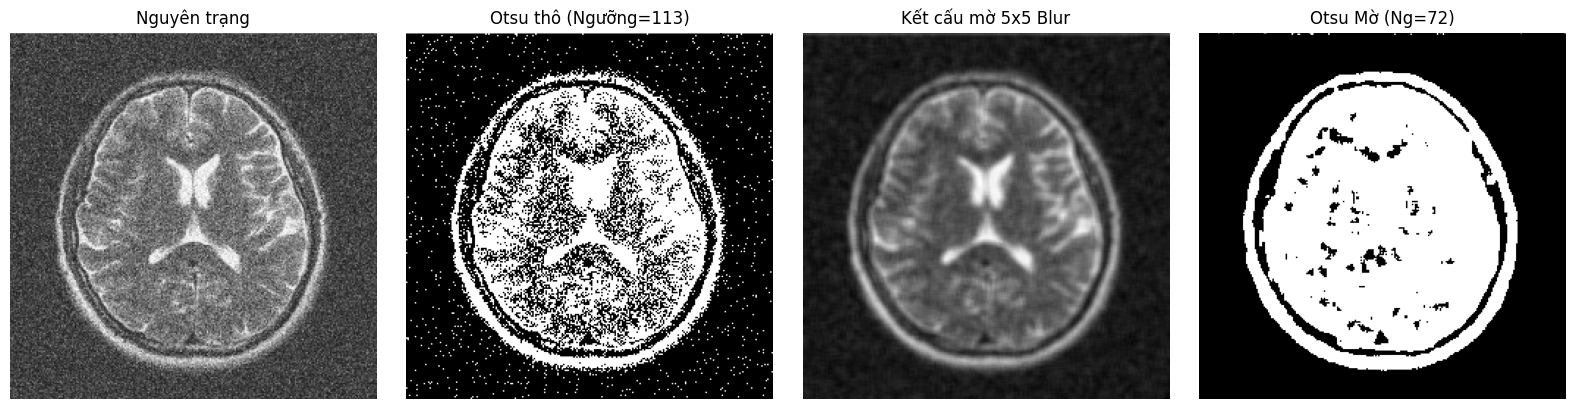


Bài tập B: Đúc hợp Khối cạnh viền hình dạng


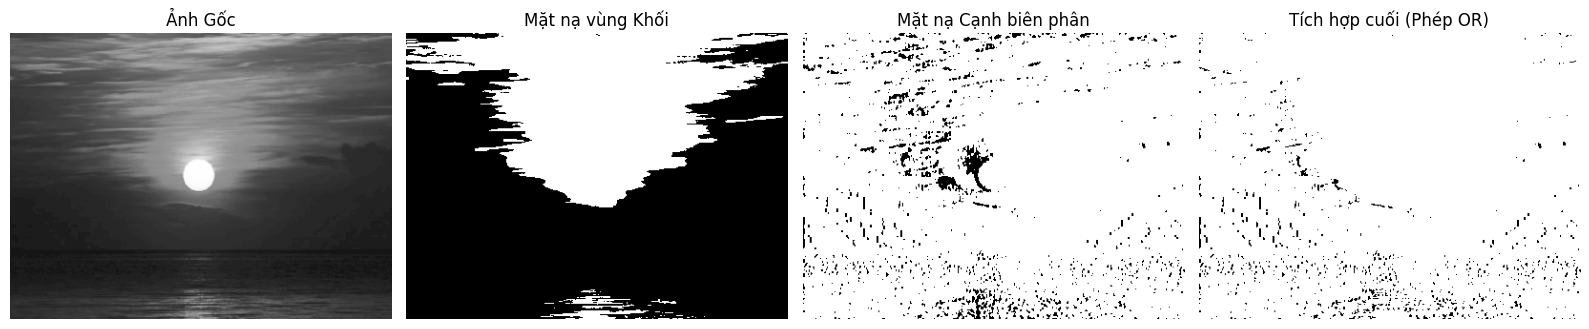

In [9]:
print("Bài tập A: Làm mềm sau đó tạo mặt nạ nhị phân (Blur then Otsu)")
# Thu nhỏ nếu file quá lớn nhằm tăng mạnh khả năng xử lý
img_task_a = cv2.resize(read_gray_cv2('../Resources/brain_noise.jpg'), (250, 250))
t_orig, mask_orig = otsu_binarize_np(img_task_a)

k_blur = kernel_box_blur(5)
# Áp dụng nhân làm mờ bằng hàm từ thu viện C của OpenCV (conv2d_cv2)
blur_a = conv2d_cv2(img_task_a, k_blur, border_type="reflect")
t_blur, mask_blur = otsu_binarize_np(blur_a)
show_multiple_gray([img_task_a, mask_orig, blur_a, mask_blur], ["Nguyên trạng", f"Otsu thô (Ngưỡng={t_orig})", "Kết cấu mờ 5x5 Blur", f"Otsu Mờ (Ng={t_blur})"])

print("\nBài tập B: Đúc hợp Khối cạnh viền hình dạng")
img_task_b = cv2.resize(read_gray_cv2('../Resources/2.png'), (400, 300))
t_otsu, mask_r = otsu_binarize_np(img_task_b)

k_sobel = kernel_sobel_x()
sobel_resp = conv2d_cv2(img_task_b, k_sobel, border_type="reflect")
mask_edge = np.where(sobel_resp >= 128, 255, 0).astype(np.uint8) # Tìm mốc vượt độ sáng tạo cạnh
fused_mask = or_images_np(mask_r, mask_edge)

show_multiple_gray([img_task_b, mask_r, mask_edge, fused_mask], ["Ảnh Gốc", "Mặt nạ vùng Khối", "Mặt nạ Cạnh biên phân", "Tích hợp cuối (Phép OR)"])
